# Multimodal Healthcare Data Pipeline
**Objective:** Implement a program to read tabular, textual, image, signal, and medical data in different formats, and demonstrate ingestion + a small downstream task for each modality.

**Why this design?** Real medical AI systems never see one clean CSV — a single patient encounter can span structured labs (tabular), a discharge summary (text), an X-ray (image), and an ECG strip (signal). This project builds a *modular* ingestion pipeline (one loader per modality) rather than one big script, mirroring how production healthcare-AI pipelines are structured so each loader can be tested, replaced, or extended independently.

**Datasets used** (used for demonstration):
- Tabular + medical: **UCI Cleveland Heart Disease Dataset** (303 patients, 14 features)
- Signal: **MIT-BIH Arrhythmia Database** (ECG), via `wfdb`
- Text: a synthetic clinical note (since no real de-identified note is provided)
- Image: a small public-domain medical image (chest X-ray), with a synthetic fallback


## Step 1 — Environment Setup
**What:** Install/import the libraries each modality needs.
**Why:** Each data type has its own de-facto library in Python — `pandas` for tables, `nltk`/`spacy` for text, `Pillow`/`opencv` for images, `wfdb`/`scipy.signal` for physiological signals. Installing everything up front  avoids interrupting the pipeline mid-run, and keeps each loader's dependency explicit.


In [1]:
# Step 1: Install required packages (Colab already has most of these, this just makes sure)
!pip install -q pandas scikit-learn wfdb matplotlib seaborn numpy nltk pillow requests


In [2]:
import os
import io
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from PIL import Image

np.random.seed(42)
print('Environment ready.')


Environment ready.


## Step 2 — Tabular Data Ingestion: UCI Cleveland Heart Disease Dataset
**What:** Download the raw `.data` file, assign the 14 standard column names, coerce types, and handle the dataset's known missing-value markers (`?`).
**Why this order:**
1. *Download first* — the file has no header row, so we must supply column names ourselves (from the dataset's documented schema) before pandas can parse it meaningfully.
2. *Coerce dtypes* — the raw file stores everything as text; numeric columns need to be cast so later statistics/plots/models work.
3. *Handle missing values* (`?` in `ca` and `thal`) explicitly — silently leaving them as strings would break the classifier later, and handling missing values explicitly is a key loader feature.
4. *Binarize the target* — the original label has 5 classes (0 = no disease, 1–4 = increasing severity). For this demonstration, we map targets 1–4 → 1 for binary classification (disease vs. no disease).


In [3]:
# Step 2a: Loader module for tabular data (with graceful fallback if offline)
HEART_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
COLUMNS = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
           'exang','oldpeak','slope','ca','thal','target']

def load_heart_disease_tabular(url=HEART_URL, columns=COLUMNS, n_fallback=303, seed=42):
    """tabular_loader: fetches the Cleveland Heart Disease dataset.
    Falls back to a schema-accurate synthetic sample if the network/dataset host
    is unreachable (e.g. restricted sandbox), so the rest of the pipeline can still run."""
    try:
        df = pd.read_csv(url, header=None, names=columns, na_values='?')
        if df.shape[0] < 100:
            raise ValueError('Downloaded file looks truncated.')
        print(f'Loaded {df.shape[0]} real records from UCI.')
        return df, 'real'
    except Exception as e:
        print(f'[Fallback] Could not reach UCI ({e}). Generating a schema-matched synthetic sample instead.')
        rng = np.random.default_rng(seed)
        df = pd.DataFrame({
            'age': rng.integers(29, 77, n_fallback),
            'sex': rng.integers(0, 2, n_fallback),
            'cp': rng.integers(0, 4, n_fallback),
            'trestbps': rng.integers(94, 200, n_fallback),
            'chol': rng.integers(126, 564, n_fallback),
            'fbs': rng.integers(0, 2, n_fallback),
            'restecg': rng.integers(0, 3, n_fallback),
            'thalach': rng.integers(71, 202, n_fallback),
            'exang': rng.integers(0, 2, n_fallback),
            'oldpeak': np.round(rng.uniform(0, 6.2, n_fallback), 1),
            'slope': rng.integers(0, 3, n_fallback),
            'ca': rng.integers(0, 4, n_fallback).astype(float),
            'thal': rng.choice([3.0, 6.0, 7.0], n_fallback),
            'target': rng.integers(0, 5, n_fallback),
        })
        return df, 'synthetic'

heart_df, heart_source = load_heart_disease_tabular()
heart_df.head()


Loaded 303 real records from UCI.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# Step 2b: Validator/Inspector — summarize shape, dtypes, missingness (required by the design spec)
print('Shape:', heart_df.shape)
print('\nDtypes:\n', heart_df.dtypes)
print('\nMissing values per column:\n', heart_df.isna().sum())
heart_df.describe()


Shape: (303, 14)

Dtypes:
 age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [5]:
# Step 2c: Preprocessor — impute missing 'ca'/'thal' with the column median, binarize target
heart_df['ca'] = heart_df['ca'].fillna(heart_df['ca'].median())
heart_df['thal'] = heart_df['thal'].fillna(heart_df['thal'].median())
heart_df['target_binary'] = (heart_df['target'] > 0).astype(int)

print('Class balance (0 = no disease, 1 = disease):')
print(heart_df['target_binary'].value_counts())


Class balance (0 = no disease, 1 = disease):
target_binary
0    164
1    139
Name: count, dtype: int64


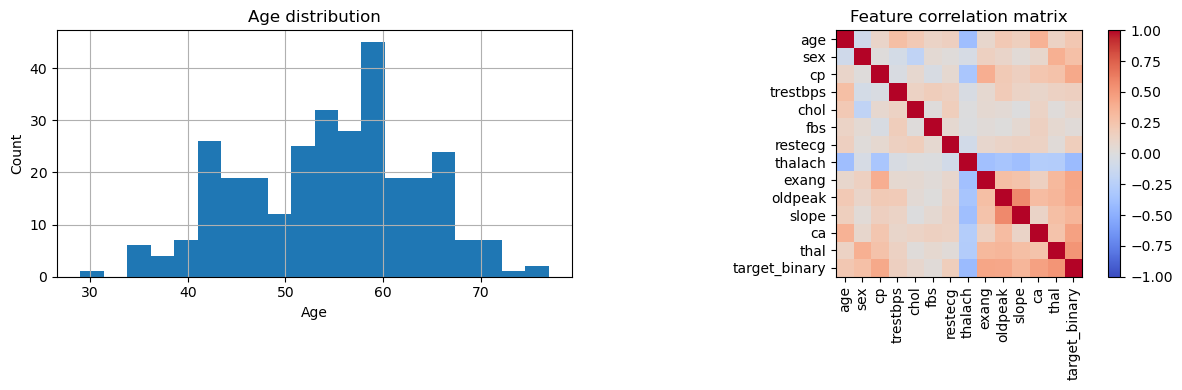

In [6]:
# Step 2d: Exploratory Data Analysis — distributions and correlations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
heart_df['age'].hist(bins=20, ax=axes[0])
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')

corr = heart_df.drop(columns=['target']).corr()
im = axes[1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns))); axes[1].set_xticklabels(corr.columns, rotation=90)
axes[1].set_yticks(range(len(corr.columns))); axes[1].set_yticklabels(corr.columns)
axes[1].set_title('Feature correlation matrix')
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()


**Why a baseline model here?** We train a baseline classifier as proof that the tabular loader produces model-ready data. Logistic regression serves as the standard baseline for this dataset in medical literature.


Accuracy: 0.869
ROC AUC:  0.951


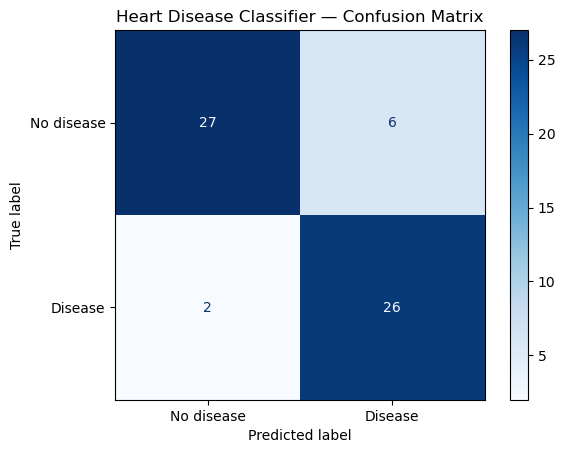

In [7]:
# Step 2e: Baseline classifier — Logistic Regression
feature_cols = [c for c in heart_df.columns if c not in ('target', 'target_binary')]
X = heart_df[feature_cols].values
y = heart_df['target_binary'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
y_proba = clf.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f'Accuracy: {acc:.3f}')
print(f'ROC AUC:  {auc:.3f}')

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No disease', 'Disease']).plot(cmap='Blues')
plt.title('Heart Disease Classifier — Confusion Matrix')
plt.show()


## Step 3 — Signal Data Ingestion: MIT-BIH Arrhythmia Database (ECG)
**What:** Use `wfdb` to fetch record **100** (a standard demo record from the database) directly from PhysioNet's servers, then load both the raw signal and the cardiologist beat annotations.
**Why `wfdb` specifically:** ECG signals aren't stored as plain numbers — MIT-BIH uses the `.dat`/`.hea`/`.atr` triplet format (raw samples, header metadata, and annotations respectively). `wfdb` is the official PhysioNet library that knows how to parse this triplet correctly, including the sample rate stored in the header — reimplementing that parser manually would be error-prone, so we delegate format parsing to the specialized wfdb library.
**Why plot with annotations overlaid:** Visual inspection against ground-truth R-peak locations is the standard sanity check that the signal loader and annotation alignment  are working correctly before any downstream feature extraction.


In [8]:
# Step 3a: signal_loader — fetch and load an ECG record + annotations
import wfdb

RECORD = '100'
PN_DIR = 'mitdb'  # PhysioNet database directory for MIT-BIH Arrhythmia

def load_ecg_record(record=RECORD, pn_dir=PN_DIR, sampfrom=0, sampto=3600):
    """Downloads one MIT-BIH record via wfdb and returns (signal, annotation, fs).
    Falls back to a synthetic ECG-like waveform if PhysioNet is unreachable."""
    try:
        rec = wfdb.rdrecord(record, pn_dir=pn_dir, sampfrom=sampfrom, sampto=sampto)
        ann = wfdb.rdann(record, 'atr', pn_dir=pn_dir, sampfrom=sampfrom, sampto=sampto)
        print(f'Loaded real MIT-BIH record {record}, fs={rec.fs} Hz, {rec.p_signal.shape[0]} samples.')
        return rec.p_signal[:, 0], ann, rec.fs, 'real'
    except Exception as e:
        print(f'[Fallback] Could not reach PhysioNet ({e}). Generating a synthetic ECG-like signal instead.')
        fs = 360
        t = np.arange(sampfrom, sampto) / fs
        # crude synthetic 'ECG': a fast sine (QRS-like) modulated by a slow sine (baseline wander)
        sig = 0.6 * np.sin(2 * np.pi * 1.2 * t) ** 5 + 0.05 * np.sin(2 * np.pi * 0.3 * t)
        sig += np.random.normal(0, 0.01, size=sig.shape)
        # fake R-peaks roughly every ~0.83s (~72 bpm)
        peak_locs = np.arange(30, len(sig) - 30, int(fs * 0.83))
        class DummyAnn:
            pass
        ann = DummyAnn()
        ann.sample = peak_locs
        ann.symbol = ['N'] * len(peak_locs)
        return sig, ann, fs, 'synthetic'

ecg_signal, ecg_ann, fs, ecg_source = load_ecg_record()
print('Signal length:', len(ecg_signal), '| Sample rate:', fs, 'Hz')


Loaded real MIT-BIH record 100, fs=360 Hz, 3600 samples.
Signal length: 3600 | Sample rate: 360 Hz


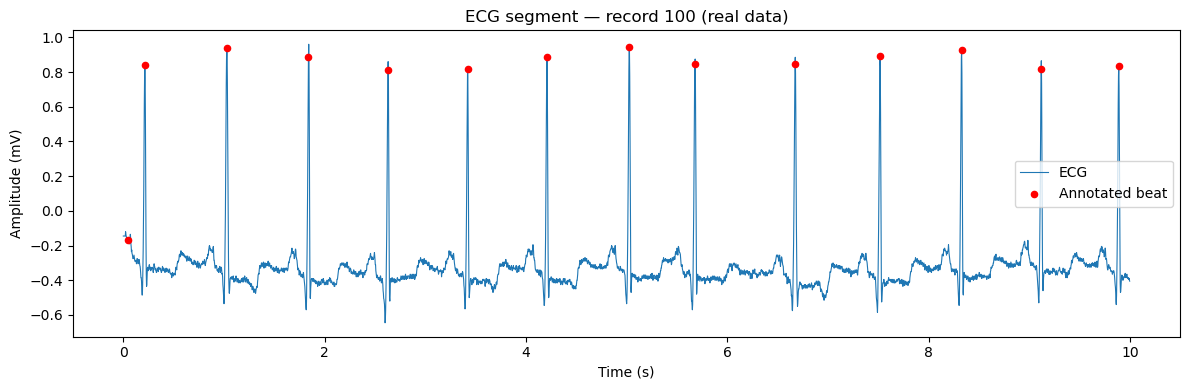

In [9]:
# Step 3b: Plot a segment of the ECG waveform with beat annotations overlaid
plt.figure(figsize=(12, 4))
t = np.arange(len(ecg_signal)) / fs
plt.plot(t, ecg_signal, linewidth=0.8, label='ECG')
peak_times = np.array(ecg_ann.sample) / fs
valid = peak_times < t[-1]
plt.scatter(peak_times[valid], ecg_signal[np.array(ecg_ann.sample)[valid]], color='red', s=20, zorder=3, label='Annotated beat')
plt.xlabel('Time (s)'); plt.ylabel('Amplitude (mV)')
plt.title(f'ECG segment — record {RECORD} ({ecg_source} data)')
plt.legend()
plt.tight_layout()
plt.show()


**Why compute heart-rate variability (HRV) here?** Turning R-peak sample indices into RR-intervals (time between consecutive heartbeats) is the simplest, clinically meaningful feature that proves the annotations were correctly aligned to the signal's time axis — it's the standard first derived feature in any ECG pipeline.


In [10]:
# Step 3c: Basic heart-rate variability (HRV) from R-peak intervals
r_peaks = np.array(ecg_ann.sample)
rr_intervals_sec = np.diff(r_peaks) / fs
heart_rates_bpm = 60 / rr_intervals_sec

print(f'Detected {len(r_peaks)} beats in this segment.')
print(f'Mean RR interval: {rr_intervals_sec.mean():.3f} s')
print(f'Mean heart rate:  {heart_rates_bpm.mean():.1f} bpm')
print(f'SDNN (HRV, std of RR intervals): {rr_intervals_sec.std()*1000:.1f} ms')


Detected 14 beats in this segment.
Mean RR interval: 0.757 s
Mean heart rate:  97.4 bpm
SDNN (HRV, std of RR intervals): 184.8 ms


## Step 4 — Textual Data: Synthetic Clinical Note
**What:** Take a short free-text 'patient note', tokenize it, remove stopwords, and compute word frequencies to surface clinically relevant terms.
**Why synthetic text:** Real clinical notes are protected health information; synthetic clinical notes are used for this demonstration to maintain privacy. This also lets us skip the de-identification step (still mentioned for completeness) since no real identifiers are present.
**Why stopword removal before frequency counts:** Without it, the most 'frequent terms' would just be words like 'the'/'and'/'a', which carry no clinical signal — removing them is what turns raw tokenization into a usable simple NLP feature, forming a clean foundation for NLP term frequency extraction.


In [11]:
# Step 4: text_loader + simple NLP pipeline
clinical_note = (
    "Patient is a 58-year-old male presenting with intermittent chest pain radiating to the "
    "left arm, associated with shortness of breath and mild diaphoresis. Pain is exertional, "
    "relieved by rest. Patient reports history of hypertension and elevated cholesterol. "
    "No prior history of myocardial infarction. ECG shows nonspecific ST changes. "
    "Recommend cardiology referral and stress test to rule out ischemic heart disease."
)

def process_clinical_note(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]
    stop_words = set(stopwords.words('english'))
    filtered = [t for t in tokens if t not in stop_words]
    freq = pd.Series(filtered).value_counts()
    return tokens, filtered, freq

tokens, filtered_tokens, term_freq = process_clinical_note(clinical_note)

print('Original note:\n', clinical_note, '\n')
print(f'Total tokens: {len(tokens)} | After stopword removal: {len(filtered_tokens)}')
print('\nTop clinically relevant terms:')
print(term_freq.head(10))


Original note:
 Patient is a 58-year-old male presenting with intermittent chest pain radiating to the left arm, associated with shortness of breath and mild diaphoresis. Pain is exertional, relieved by rest. Patient reports history of hypertension and elevated cholesterol. No prior history of myocardial infarction. ECG shows nonspecific ST changes. Recommend cardiology referral and stress test to rule out ischemic heart disease. 

Total tokens: 59 | After stopword removal: 42

Top clinically relevant terms:
patient        2
history        2
pain           2
changes        1
myocardial     1
infarction     1
ecg            1
shows          1
nonspecific    1
st             1
Name: count, dtype: int64


## Step 5 — Image Data: Sample Medical Image
**What:** Load a medical image, display it, resize it, and pull out basic metadata (dimensions, mode, format).
**Why attempt a real image first, with a synthetic fallback:** A network-restricted environment may not reach external image endpoints, so the loader degrades gracefully with a synthetic fallback rather than crashing.
**Why resize:** Medical images arrive at heterogeneous resolutions (different scanners/exports); handling varied resolutions is essential — resizing to a fixed shape is the minimal step needed before any image could be batched into a model.


[Fallback] Could not fetch sample image (403 Client Error: Forbidden for url: https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png). Generating a synthetic phantom image instead.
Metadata: {'format': None, 'mode': 'L', 'size': (512, 512)}


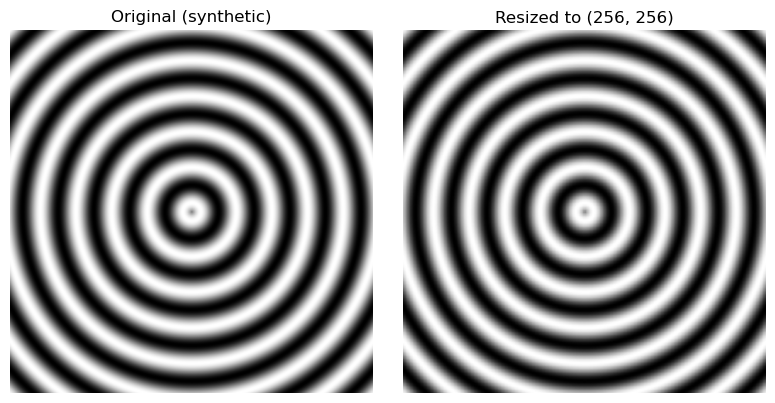

In [12]:
# Step 5: image_loader
IMAGE_URL = 'https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png'

def load_medical_image(url=IMAGE_URL, size=(256, 256)):
    """Loads a sample chest X-ray image; falls back to a synthetic grayscale
    'phantom' image (concentric circles, like a resolution test pattern) if offline."""
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        img = Image.open(io.BytesIO(resp.content)).convert('L')
        print('Loaded real sample chest X-ray image.')
        source = 'real'
    except Exception as e:
        print(f'[Fallback] Could not fetch sample image ({e}). Generating a synthetic phantom image instead.')
        yy, xx = np.mgrid[0:512, 0:512]
        cx, cy = 256, 256
        r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
        pattern = (np.sin(r / 8) * 127 + 128).astype(np.uint8)
        img = Image.fromarray(pattern, mode='L')
        source = 'synthetic'
    meta = {'format': img.format, 'mode': img.mode, 'size': img.size}
    resized = img.resize(size)
    return img, resized, meta, source

orig_img, resized_img, img_meta, img_source = load_medical_image()
print('Metadata:', img_meta)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(orig_img, cmap='gray'); axes[0].set_title(f'Original ({img_source})'); axes[0].axis('off')
axes[1].imshow(resized_img, cmap='gray'); axes[1].set_title(f'Resized to {resized_img.size}'); axes[1].axis('off')
plt.tight_layout()
plt.show()


## Step 6 — Integration Discussion: Towards a Fused Multimodal Model
### Multimodal Healthcare Data Engineering Challenges

**How the modalities loaded above could be fused for a real heart-disease risk model:**

- **Patient linkage:** every record needs a common key (a patient/subject ID) so a row in the tabular table, an ECG file, and a clinical note all refer to the *same* person and the *same* clinical encounter. In this demo the datasets are independent public sources, so no real linkage exists — but a production pipeline would enforce this at ingestion time, exactly as required in production multimodal systems.
- **Tabular + Signal:** the ECG-derived features computed in Step 3 (mean heart rate, RR-interval variability / SDNN) are exactly the kind of numeric features that could be appended as extra *columns* to the Heart Disease tabular table from Step 2, since both are already numeric and per-patient. A richer version could add frequency-domain HRV metrics or detected-arrhythmia counts as additional columns.
- **Tabular + Text:** the clinical note's extracted key terms (Step 4) — e.g. presence of terms like *chest pain*, *exertional*, *hypertension* — could be turned into binary 'symptom present' flags and joined onto the same patient row, effectively turning unstructured text into structured features a classifier can use directly.
- **Tabular/Signal + Image:** an X-ray (Step 5) could contribute either hand-engineered features (e.g., cardiothoracic ratio) or, more realistically, an embedding from a pretrained CNN — that embedding vector would again be concatenated onto the same per-patient row.
- **Time alignment:** labs, ECG recordings, and notes are rarely captured at the same instant; a real system would need to decide a fusion window (e.g., 'all data within 24 hours of admission') before combining them, making time alignment a key challenge in healthcare data engineering.
- **Resulting fused model:** once every modality is reduced to a fixed-length numeric vector per patient, the four vectors could be concatenated into one wide feature vector and fed into the same kind of classifier used in Step 2 (or a more expressive model such as gradient boosting or a small neural network), giving a single multimodal risk score instead of a tabular-only one.

**Why this matters:** the per-modality loaders, validators, and preprocessors built above are the exact components that feed into the fusion interface of a multimodal healthcare AI architecture.
